In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

ips_order <- c('IPS_main', 'IPS_alt')
ips_hexes <- c('#1FB560', '#571B63')

umap_theme <- theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: pluripotency and early/mature-IPS marker genes

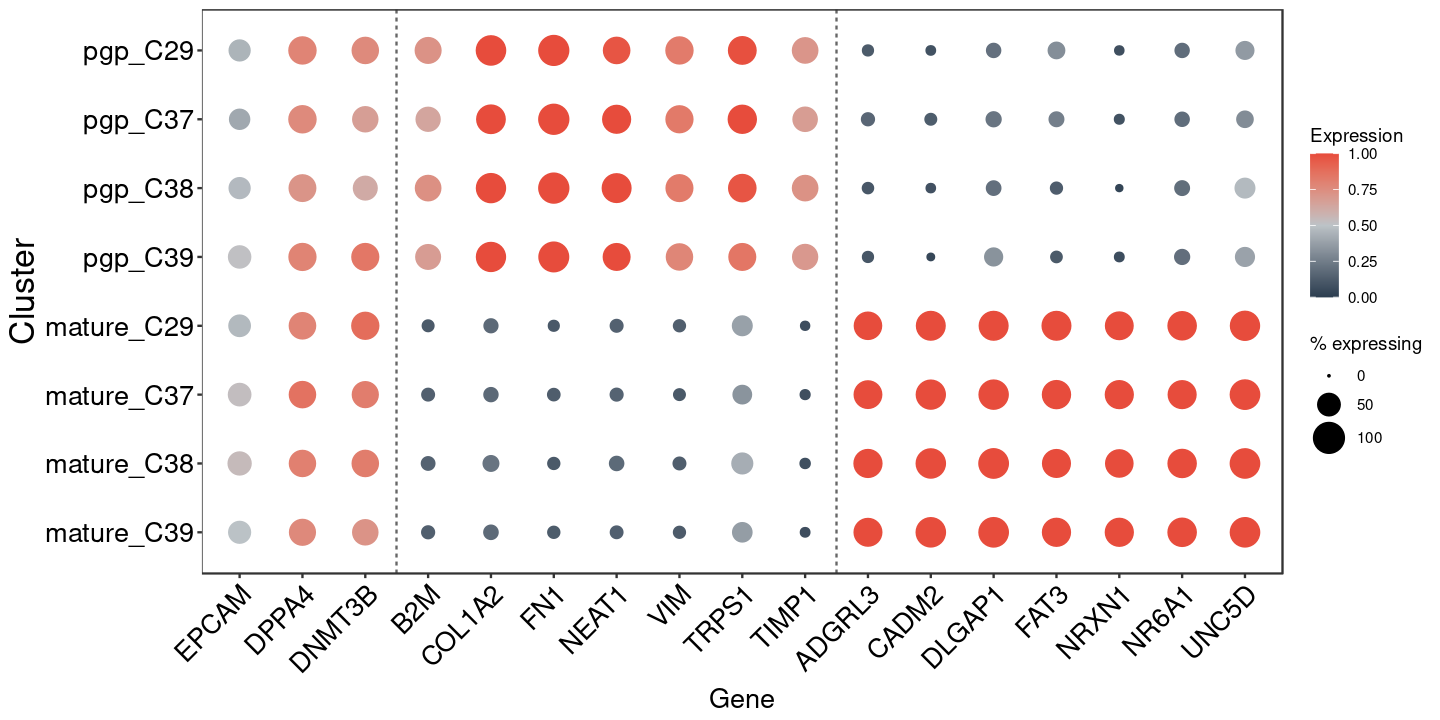

In [ ]:
batch_order <- rev(c(paste0('pgp_', donors), paste0('mature_', donors)))

mature_markers_path = paste0(projdir, '/csv/figure5/mature_marker_genes.csv')
mature_markers = as.data.frame(fread(mature_markers_path, sep='\t'))
mature_markers$variable <- factor(mature_markers$variable, levels=unique(mature_markers$variable))
mature_markers$batch_donor <- factor(mature_markers$batch_donor, levels=batch_order)

dot_df <- mature_markers %>%
  group_by(batch_donor, variable) %>%
  summarise(
    avg_expr = mean(value),
    pct_expr = mean(value > 0.5) * 100,
    .groups = "drop"
  )

w = 12
h = 6
options(repr.plot.width=w, repr.plot.height=h)

gene_levels <- levels(factor(dot_df$variable))
dnmt3b_pos <- which(gene_levels == "DNMT3B")
timp1_pos  <- which(gene_levels == "TIMP1")

ggplot(dot_df, aes(x = variable, y = batch_donor)) +
  geom_vline(xintercept = c(dnmt3b_pos + 0.5, timp1_pos + 0.5),
             linewidth = 0.5, linetype = "dashed", color = "grey40") +
  geom_point(aes(size = pct_expr, color = avg_expr)) +
  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 1), oob = scales::squish) +
  scale_size_area(max_size = 8, breaks = c(0, 50, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=16, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background  = element_blank(),
  )

### B: GO terms of early/mature-IPS DEGs

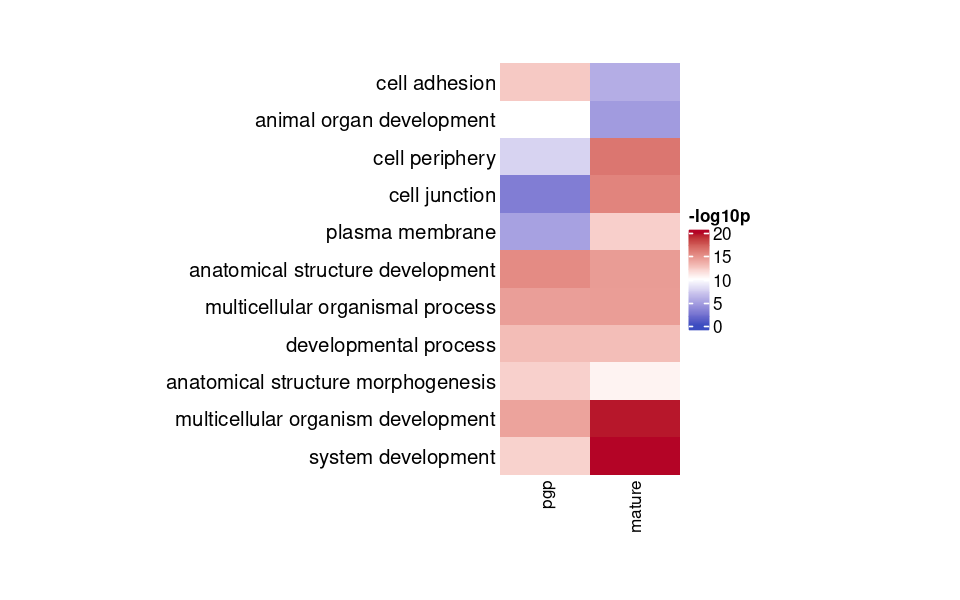

In [ ]:
mature_go_path = paste0(projdir, '/csv/figure5/pgp_mature_go.csv')
mature_go = as.data.frame(fread(mature_go_path, sep='\t'))
rownames(mature_go) <- mature_go[,1]
mature_go <- mature_go[,-1]

w = 8
h = 5
options(repr.plot.width=w, repr.plot.height=h)

col_fun <- colorRamp2(c(0, 10, 20), c("#3B4CC0", "white", "#B40426"))
ht <- Heatmap(mature_go,
        name = "-log10p",
        col = col_fun,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 12),
        column_names_gp = gpar(fontsize = 10, rot = 90),
        heatmap_width = unit(10, "cm"),
        heatmap_height = unit(10, "cm"))

ht

### C: number of differential peaks

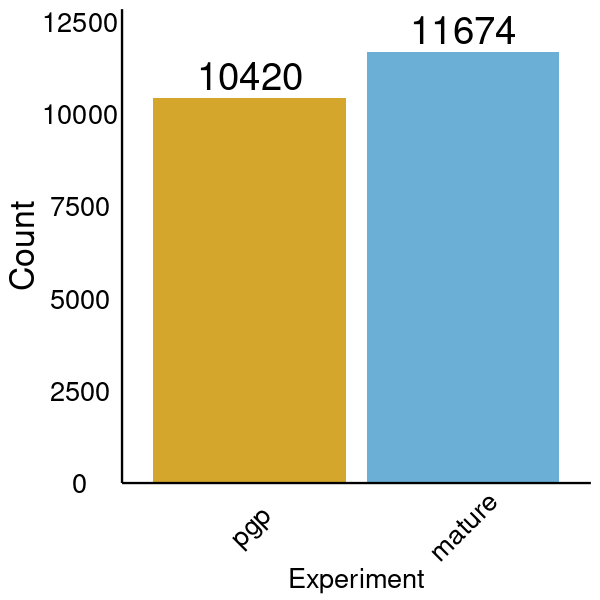

In [ ]:
exp_order <- c('pgp', 'mature')
exp_hexes <- c('#D4A72C', '#6BAED6')

diff_peaks_count_path = paste0(projdir, '/csv/figure5/mature_pgp_diff_peak_count.csv')
diff_peaks_count = as.data.frame(fread(diff_peaks_count_path, sep='\t'))
diff_peaks_count$variable <- factor(diff_peaks_count$variable, levels=exp_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(diff_peaks_count, aes(x = variable, y = value, fill = variable) )+
  geom_bar(stat='identity', position='dodge') +
  geom_text(
    aes(label = value),
    vjust = -0.3,
    size = 8
  ) +
  labs(x='Experiment', y='Count') +
  theme_bw() +
  umap_theme +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  theme(
    axis.text.x = element_text(size=16, angle = 45, hjust = 0.5, color='black'),
    axis.text.y = element_text(size=16, angle = 0, hjust = 0.5, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    axis.line.x = element_line(color='black'),
    axis.line.y = element_line(color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
      legend.position='none'
  ) + scale_fill_manual(values=exp_hexes)

### D: 3C UMAP, cluster and IPS-LE/IPS-SE

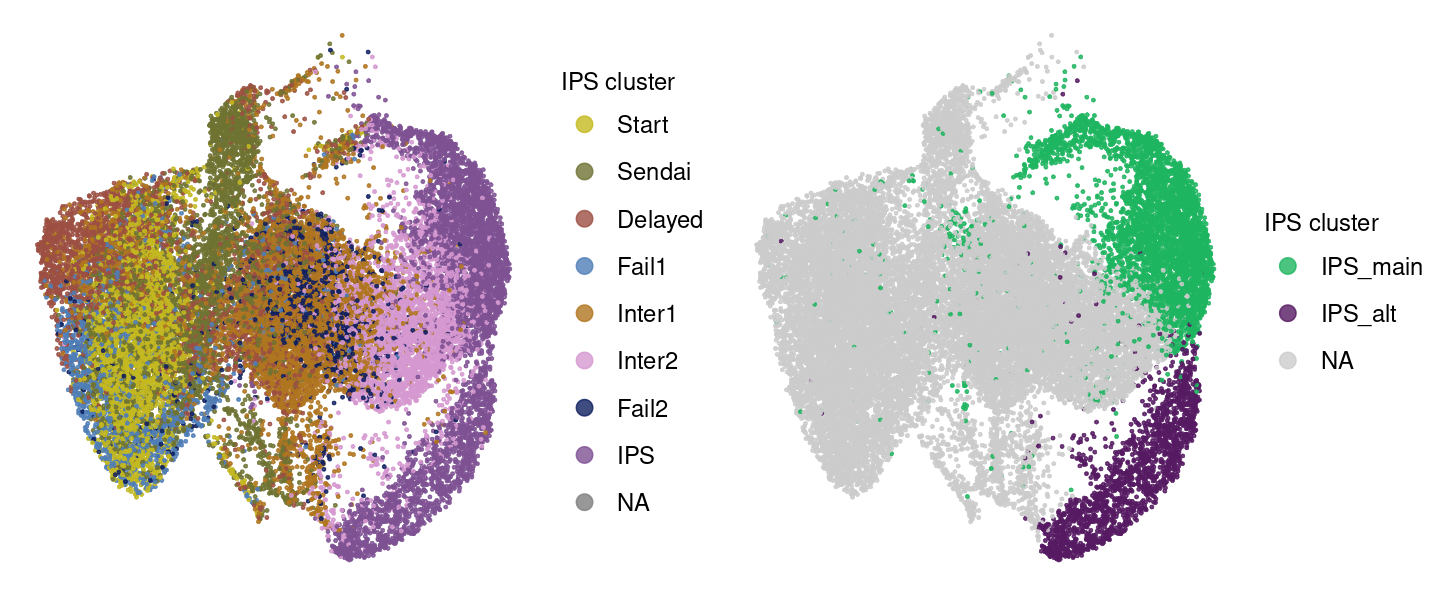

In [ ]:
hic_path = paste0(projdir, '/csv/figure2/hic_donor_umap.csv')
hic_umap = as.data.frame(fread(hic_path, sep='\t'))
hic_umap$donor <- factor(hic_umap$donor, levels=donors)
rownames(hic_umap) <- hic_umap$wellprefix

clusters_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/mc/csv/label_transfer/xgboost_time_v7.csv'
clusters <- as.data.frame(fread(clusters_path, sep='\t'))
rownames(clusters) <- clusters$wellprefix
ips_clusters_path <- '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/mc/csv/label_transfer/snm3c_ips_subtype.csv'
ips_clusters <- as.data.frame(fread(ips_clusters_path, sep='\t'))
rownames(ips_clusters) <- ips_clusters$V1
hic_umap$cluster <- clusters[hic_umap$wellprefix,]$cluster
hic_umap <- hic_umap[!is.na(hic_umap$cluster),]
hic_umap$cluster <- factor(hic_umap$cluster, levels=tmp_order)
hic_umap$ips_cluster <- ips_clusters[hic_umap$wellprefix,]$ips_subtype
hic_umap$ips_cluster[is.na(hic_umap$ips_cluster)] <- "other"
hic_umap$ips_cluster <- factor(hic_umap$ips_cluster, levels=ips_order)

set.seed(1)
shuffled_hic_umap <- hic_umap[sample(nrow(hic_umap)), ]

p1 <- ggplot(shuffled_hic_umap, aes(x = umap0, y = umap1, color = cluster)) +
  geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14)) +
    scale_color_manual(values = clust_hexes) +
          guides(color = guide_legend(override.aes = list(size = 4)))

p2 <- ggplot(shuffled_hic_umap, aes(x = umap0, y = umap1, color = ips_cluster)) +
  geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14)) +
    scale_color_manual(values = ips_hexes, na.value = "grey80") +
          guides(color = guide_legend(override.aes = list(size = 4)))

w = 12
h = 5
options(repr.plot.width=w, repr.plot.height=h)

plot_grid(p1, p2)

### E: per-cell contact distance distributions

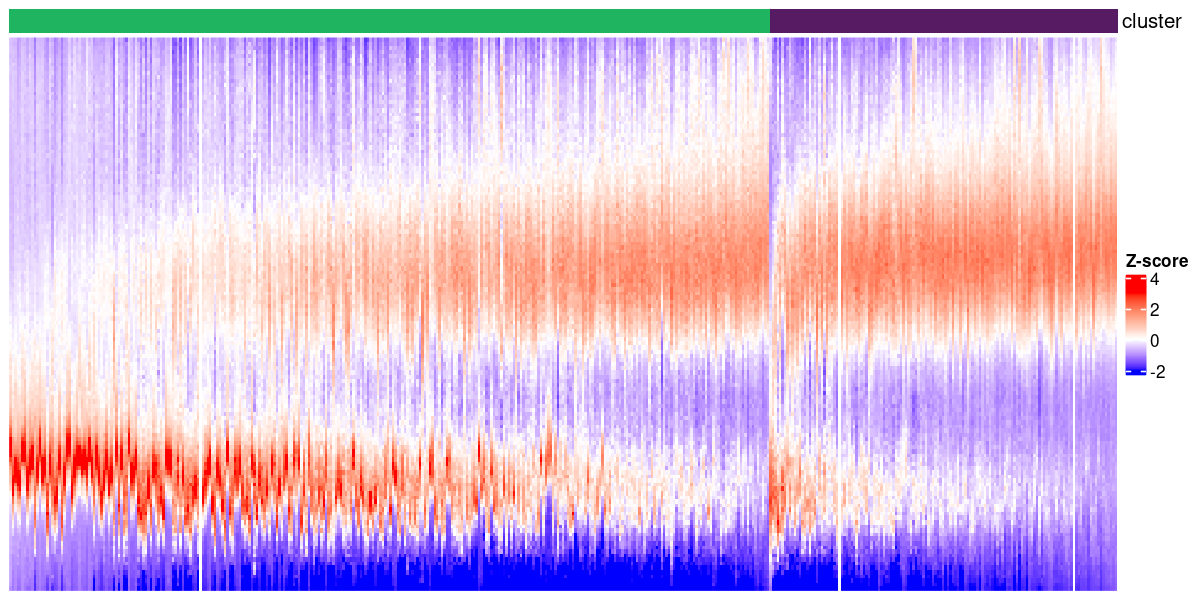

In [ ]:
ips_path = paste0(projdir, '/csv/figure5/ips_subtypes_dist_df.csv')
ips_dists = as.data.frame(fread(ips_path))
ips_dists <- ips_dists[,-1]

ips_path = paste0(projdir, '/csv/figure5/ips_subtypes_dist_meta.csv')
ips_dists_meta = as.data.frame(fread(ips_path))

ips_order <- c('IPS_main', 'IPS_alt')
ips_hexes <- c('#1FB560', '#571B63')

cluster <- factor(ips_dists_meta$ips_subtype)
cluster_palette_named <- setNames(ips_hexes, ips_order)

ha_col <- HeatmapAnnotation(
  cluster = cluster,
  col = list(cluster = cluster_palette_named),
  show_annotation_name = TRUE,
    show_legend = FALSE
)

w = 10
h = 5
options(repr.plot.width=w, repr.plot.height=h)

p1 <- Heatmap(
  ips_dists,
  name = "Z-score",
  col = colorRamp2(c(-2, 0, 3), c("blue", "white", "red")),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  top_annotation = ha_col,
  use_raster=TRUE
)

p <- as.ggplot(p1)
p

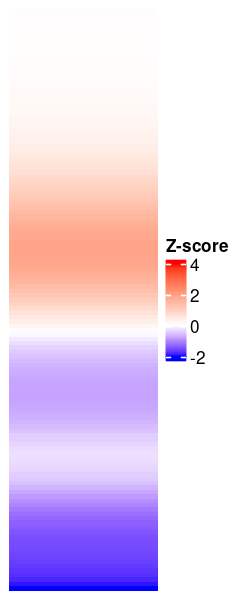

In [ ]:
pub_dists_path = paste0(projdir, '/csv/figure5/4dn_mature_ips_contact_dist.csv')
pub_dists = as.data.frame(fread(pub_dists_path, sep='\t'))
pub_dists <- as.data.frame(pub_dists[,-1])
colnames(pub_dists) <- c('zscore')

w = 2
h = 5
options(repr.plot.width=w, repr.plot.height=h)

p1 <- Heatmap(
  pub_dists,
  name = "Z-score",
  col = colorRamp2(c(-2, 0, 4), c("blue", "white", "red")),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = FALSE,
  show_column_names = FALSE,
  use_raster=FALSE
)

p <- as.ggplot(p1)
p

### G: methylation UMAP, IPS-LE/IPS-SE

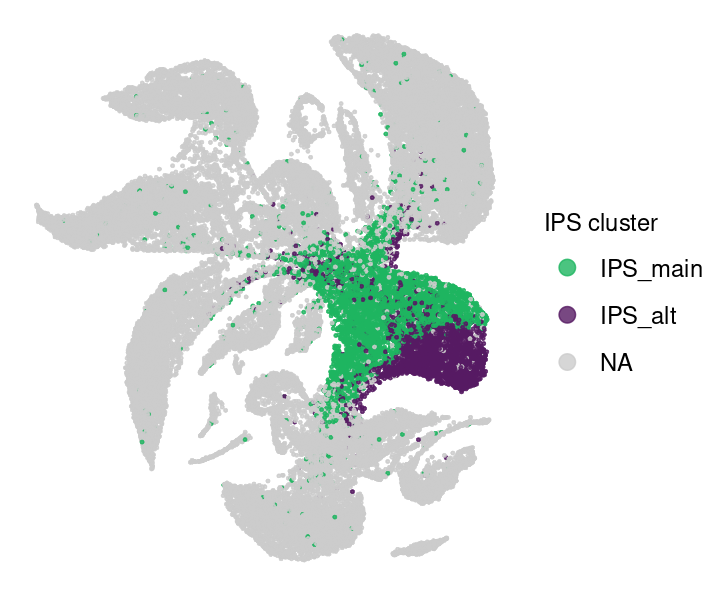

In [ ]:
mcg_umap_path = paste0(projdir, '/csv/figure5/snmct_snm3c_mcg_ips_subtype_umap.csv')
mcg_umap = as.data.frame(fread(mcg_umap_path, sep='\t'))
mcg_umap$ips_subtype <- factor(mcg_umap$ips_subtype, levels=ips_order)

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]

ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = ips_subtype)) +
  geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14)) +
    scale_color_manual(values = ips_hexes, na.value = "grey80") +
          guides(color = guide_legend(override.aes = list(size = 4)))

### H: mCG correlation with mature-IPS

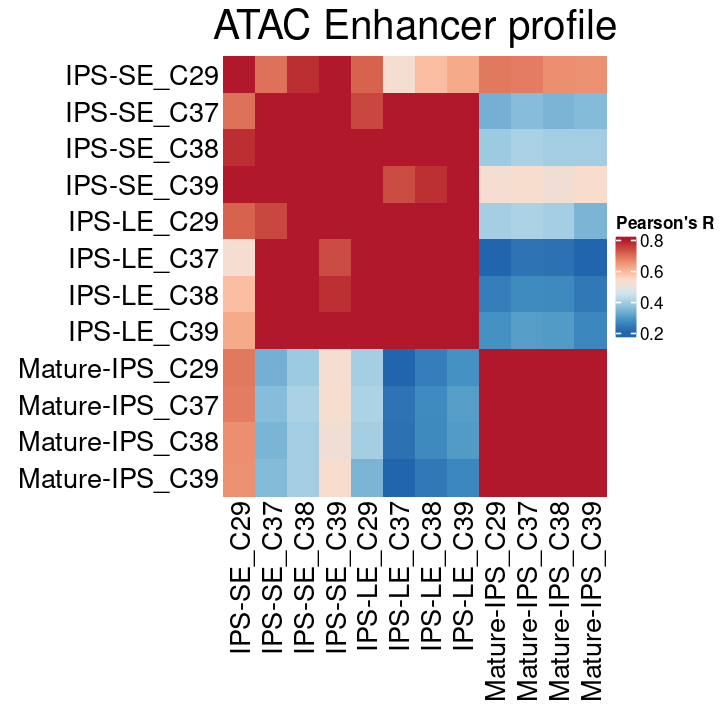

In [ ]:
mcg_df_path = paste0(projdir, '/csv/figure5/ips_subtype_mcg_mature_corr.csv')
mcg_df = as.data.frame(fread(mcg_df_path, sep='\t'))
rownames(mcg_df) <- mcg_df[,1]
mcg_df <- mcg_df[,-1]

rownames(mcg_df) <- gsub('IPS_alt', 'IPS-SE', rownames(mcg_df))
rownames(mcg_df) <- gsub('IPS_main', 'IPS-LE', rownames(mcg_df))
rownames(mcg_df) <- gsub('_IPS', '_Mature-IPS', rownames(mcg_df))
colnames(mcg_df) <- gsub('IPS_alt', 'IPS-SE', colnames(mcg_df))
colnames(mcg_df) <- gsub('IPS_main', 'IPS-LE', colnames(mcg_df))
colnames(mcg_df) <- gsub('_IPS', '_Mature-IPS', colnames(mcg_df))

col_fun <- colorRamp2(seq(0.2, 0.8, length.out = 8), rev(brewer.pal(8, "RdBu")))

rownames(mcg_df) <- recode(rownames(mcg_df),
  "C29_Mature-IPS" = "Mature-IPS_C29",
  "C37_Mature-IPS" = "Mature-IPS_C37",
  "C38_Mature-IPS" = "Mature-IPS_C38",
  "C39_Mature-IPS" = "Mature-IPS_C39"
)

colnames(mcg_df) <- recode(colnames(mcg_df),
  "C29_Mature-IPS" = "Mature-IPS_C29",
  "C37_Mature-IPS" = "Mature-IPS_C37",
  "C38_Mature-IPS" = "Mature-IPS_C38",
  "C39_Mature-IPS" = "Mature-IPS_C39"
)

w = 6
h = 6
options(repr.plot.width = w, repr.plot.height = h)

ht <- Heatmap(
    mcg_df,
    name = "Pearson's R",
    col = col_fun,
    row_names_side = "left",
    column_names_side = "bottom",
    show_row_names = TRUE,
    show_column_names = TRUE,
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_gp = gpar(fontsize = 16),
    column_names_gp = gpar(fontsize = 16),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    row_title_rot = 90,
    column_title = 'ATAC Enhancer profile')

ht

### I: early-IPS methylation UMAP, IPS subtype and donor

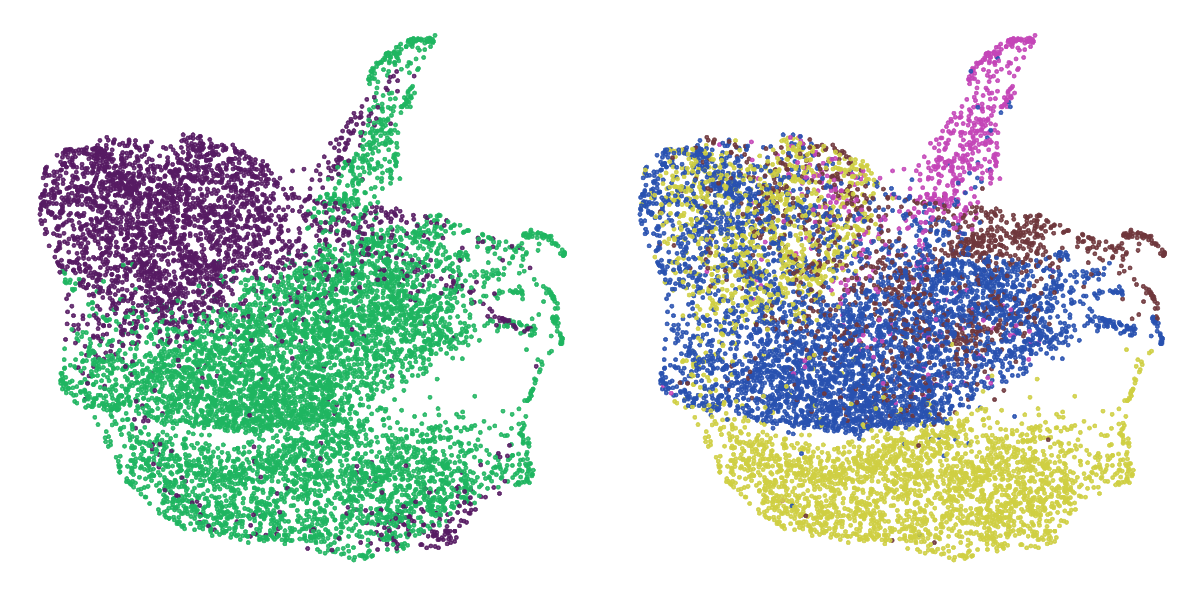

In [ ]:
ips_order <- c('IPS_main', 'IPS_alt')
ips_hexes <- c('#1FB560', '#571B63')

mcg_umap_path = paste0(projdir, '/csv/figure5/ips_subtype_mcg_umap_df.csv')
mcg_umap = as.data.frame(fread(mcg_umap_path, sep='\t'))
mcg_umap$ips_subtype <- factor(mcg_umap$ips_subtype, levels=ips_order)

set.seed(1)
shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]

w = 10
h = 5
options(repr.plot.width=w, repr.plot.height=h)

p1 <- ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = ips_subtype)) +
    geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(legend.position = 'none') +
        scale_color_manual(values = ips_hexes)

p2 <- ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = line)) +
    geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", color='IPS cluster') +
  theme_bw() +
  umap_theme +
   theme(legend.position = 'none') +
        scale_color_manual(values = donor_hexes)

plot_grid(p1, p2)

### J: nearest neighbors from the same donor

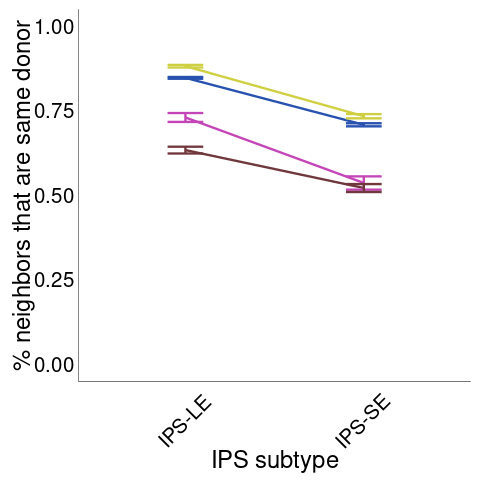

In [ ]:
ips_order <- c('IPS-LE', 'IPS-SE')
ips_hexes <- c('#1FB560', '#571B63')
names(ips_hexes) <- ips_order

mcg_nn_path = paste0(projdir, '/csv/figure5/ips_subtype_nn_prop.csv')
mcg_nn = as.data.frame(fread(mcg_nn_path, sep='\t'))
mcg_nn$ips_subtype <- gsub('IPS_alt', 'IPS-SE', mcg_nn$ips_subtype)
mcg_nn$ips_subtype <- gsub('IPS_main', 'IPS-LE', mcg_nn$ips_subtype)
mcg_nn$ips_subtype <- factor(mcg_nn$ips_subtype, levels=ips_order)

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(mcg_nn, aes(x = ips_subtype, y = donor_prop, color = line, group = line)) +
  stat_summary(fun.data = mean_se, geom = "line") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
  labs(x = "IPS subtype", y = "% neighbors that are same donor", color = 'Donor') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
   umap_theme +
   theme(axis.text.x = element_text(size=12,angle=45, color='black', vjust=0.4),
        axis.text.y = element_text(size=12,angle=0, color='black'),
        axis.title.x = element_text(size=14),
        axis.title.y = element_text(size=14, angle=90),
        axis.line = element_line(linewidth=0.1)) +
        scale_color_manual(values = donor_hexes)

### K: mean insulation at TAD boundaries

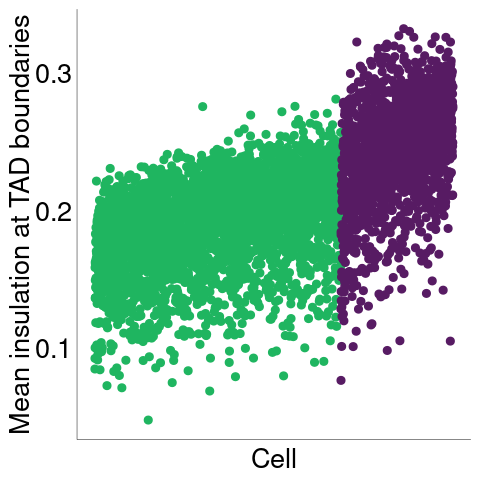

In [ ]:
ips_order <- c('IPS-LE', 'IPS-SE')
ips_hexes <- c('#1FB560', '#571B63')

insulation_path <- paste0(projdir, '/csv/figure5/ips_main_alt_insulation.csv')
insulation = as.data.frame(fread(insulation_path, sep='\t'))
insulation$ips_subtype <- gsub('IPS_alt', 'IPS-SE', insulation$ips_subtype)
insulation$ips_subtype <- gsub('IPS_main', 'IPS-LE', insulation$ips_subtype)
insulation$ips_subtype <- factor(insulation$ips_subtype, levels=ips_order)

w = 4
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(insulation, aes(x = idx, y = insulation, color = ips_subtype)) +
  geom_point() +
  labs(x = "Cell", y = "Mean insulation at TAD boundaries") +
  theme_bw() +
  umap_theme +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_text(size=16, angle = 0, hjust = 1, color='black'),
    axis.line.x = element_line(linewidth=0.1, color='black'),
    axis.line.y = element_line(linewidth=0.1, color='black'),
    axis.title.x = element_text(size=16, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=16, angle = 90, vjust=1, color='black')) +
  scale_color_manual(values=ips_hexes)

In [ ]:
sessionInfo()

In [ ]:
Sys.time()